# Assignment 2: COVID-19 Data Analysis Using Python (Pandas)
**University of Management & Technology**  
**Department of Artificial Intelligence** 

**Name**: Aleena
**Roll.no**: F2024376319

**Subject:** Programming for AI (AI271)  
**Instructor:** Dr. M. Wasim Nawaz  
**Semester:** Spring 2026

In [10]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [11]:
import os
for file in os.listdir('/kaggle/input/datasets'):
    print(file)

imdevskp


In [12]:
import os
for file in os.listdir('/kaggle/input/datasets/imdevskp'):
    print(file)

corona-virus-report


In [13]:
import os
for file in os.listdir('/kaggle/input/datasets/imdevskp/corona-virus-report'):
    print(file)

covid_19_clean_complete.csv
country_wise_latest.csv
day_wise.csv
usa_county_wise.csv
worldometer_data.csv
full_grouped.csv


---
## Part A: Data Loading and Exploration

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (49068, 10)


In [15]:
# Display first 5 rows
print("=== First 5 Rows ===")
df.head(5)

=== First 5 Rows ===


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [16]:
# Display last 5 rows
print("=== Last 5 Rows ===")
df.tail(5)

=== Last 5 Rows ===


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe
49067,NaN,Lesotho,-29.610000,28.233600,2020-07-27,505,12,128,365,Africa


In [17]:
# Dataset structure and data types
print("=== Dataset Structure (info) ===")
df.info()

=== Dataset Structure (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [18]:
# Statistical summary of numerical columns
print("=== Statistical Summary (Numerical Columns) ===")
df.describe()

=== Statistical Summary (Numerical Columns) ===


,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [19]:
# Summary of categorical columns
print("=== Summary of Categorical Columns ===")
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns: {list(categorical_cols)}")
print()
for col in categorical_cols:
    print(f"--- {col} ---")
    print(f"  Unique values : {df[col].nunique()}")
    print(f"  Null count    : {df[col].isnull().sum()}")
    print(f"  Top 3 values  : {df[col].value_counts().head(3).to_dict()}")
    print()

=== Summary of Categorical Columns ===
Categorical columns: ['Province/State', 'Country/Region', 'Date', 'WHO Region']

--- Province/State ---
  Unique values : 78
  Null count    : 34404
  Top 3 values  : {'Australian Capital Territory': 188, 'New South Wales': 188, 'Northern Territory': 188}

--- Country/Region ---
  Unique values : 187
  Null count    : 0
  Top 3 values  : {'China': 6204, 'Canada': 2256, 'France': 2068}

--- Date ---
  Unique values : 188
  Null count    : 0
  Top 3 values  : {'2020-01-22': 261, '2020-01-23': 261, '2020-01-24': 261}

--- WHO Region ---
  Unique values : 6
  Null count    : 0
  Top 3 values  : {'Europe': 15040, 'Western Pacific': 10340, 'Africa': 9024}



---
## Part B: Data Cleaning and Preprocessing

In [20]:
# Identify missing values
print("=== Missing Values Per Column ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values Per Column ===
                Missing Count  Missing %
Province/State          34404      70.11


In [23]:
# Analyze Province/State column for null values
print("=== Province/State Column Analysis ===")
total_rows = len(df)
null_province = df['Province/State'].isnull().sum()
filled_province = df['Province/State'].notnull().sum()

print(f"Total rows          : {total_rows}")
print(f"Null Province/State : {null_province} ({null_province/total_rows*100:.1f}%)")
print(f"Filled Province/State: {filled_province} ({filled_province/total_rows*100:.1f}%)")
print()
print("Countries that DO have province-level data (sample):")
print(df[df['Province/State'].notnull()]['Country/Region'].unique()[:10])
print()
print("""
Explanation:
The 'Province/State' column contains null values because most countries report 
COVID-19 data at the national level only also there is no sub national breakdown. 
Only a few large countries like the USA, Canada, China, and Australia report 
data at the province/state level. For all other countries, this field is 
intentionally left blank (NaN), which is expected and not an error.
""")

=== Province/State Column Analysis ===
Total rows          : 49068
Null Province/State : 34404 (70.1%)
Filled Province/State: 14664 (29.9%)

Countries that DO have province-level data (sample):
['Australia' 'Canada' 'China' 'Denmark' 'Greenland' 'France' 'Netherlands'
 'United Kingdom']


Explanation:
The 'Province/State' column contains null values because most countries report 
COVID-19 data at the national level only also there is no sub national breakdown. 
Only a few large countries like the USA, Canada, China, and Australia report 
data at the province/state level. For all other countries, this field is 
intentionally left blank (NaN), which is expected and not an error.



In [24]:
# Remove unnecessary columns and justify
print("=== Columns Before Dropping ===")
print(df.columns.tolist())

# 'Province/State' is mostly null (>60%) and is not needed for country-level analysis
# 'Lat' and 'Long' are geographic coordinates; useful for maps but not for statistical analysis here
cols_to_drop = ['Province/State', 'Lat', 'Long']
df_clean = df.drop(columns=cols_to_drop)

print()
print("=== Columns After Dropping ===")
print(df_clean.columns.tolist())
print()
print("Justification:")
print("  - 'Province/State' : Over 60% null; we analyze at country level")
print("  - 'Lat', 'Long'    : Geographic coordinates, not needed for statistical analysis")

=== Columns Before Dropping ===
['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']

=== Columns After Dropping ===
['Country/Region', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']

Justification:
  - 'Province/State' : Over 60% null; we analyze at country level
  - 'Lat', 'Long'    : Geographic coordinates, not needed for statistical analysis


In [25]:
# Rename columns for clarity
df_clean = df_clean.rename(columns={
    'Country/Region': 'Country',
    'Date'          : 'Date',
    'Confirmed'     : 'Confirmed_Cases',
    'Deaths'        : 'Deaths',
    'Recovered'     : 'Recovered',
    'Active'        : 'Active_Cases',
    'WHO Region'    : 'WHO_Region'
})

print("=== Renamed Columns ===")
print(df_clean.columns.tolist())
print()
print("Justification:")
print("  - 'Country/Region' → 'Country'        : Simpler and avoids special characters")
print("  - 'Confirmed'      → 'Confirmed_Cases' : More descriptive")
print("  - 'Active'         → 'Active_Cases'    : More descriptive")
print("  - 'WHO Region'     → 'WHO_Region'      : Removes space for easier column access")

=== Renamed Columns ===
['Country', 'Date', 'Confirmed_Cases', 'Deaths', 'Recovered', 'Active_Cases', 'WHO_Region']

Justification:
  - 'Country/Region' → 'Country'        : Simpler and avoids special characters
  - 'Confirmed'      → 'Confirmed_Cases' : More descriptive
  - 'Active'         → 'Active_Cases'    : More descriptive
  - 'WHO Region'     → 'WHO_Region'      : Removes space for easier column access


In [26]:
# Check for duplicate records
duplicates = df_clean.duplicated().sum()
print("=== Duplicate Records ===")
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("Duplicates found! Removing them...")
    df_clean = df_clean.drop_duplicates()
    print(f"Shape after removing duplicates: {df_clean.shape}")
else:
    print("No duplicate rows found. Dataset is clean in this regard.")

=== Duplicate Records ===
Number of duplicate rows: 1896
Duplicates found! Removing them...
Shape after removing duplicates: (47172, 7)


---
## Part C: Data Analysis

In [27]:
# Get the latest snapshot per country (most recent date for each country)
# This avoids double-counting cumulative daily records
latest_df = df_clean.groupby('Country').agg({
    'Deaths'    : 'max',
    'Recovered' : 'max',
    'Confirmed_Cases': 'max',
    'Active_Cases'   : 'max',
    'WHO_Region'     : 'first'
}).reset_index()

print(f"Latest snapshot DataFrame shape: {latest_df.shape}")
latest_df.head()

Latest snapshot DataFrame shape: (187, 6)


,Country,Deaths,Recovered,Confirmed_Cases,Active_Cases,WHO_Region
0,Afghanistan,1269,25198,36263,20311,Eastern Mediterranean
1,Albania,144,2745,4880,1991,Europe
2,Algeria,1163,18837,27973,8114,Africa
3,Andorra,52,803,907,504,Europe
4,Angola,41,242,950,667,Africa


In [28]:
# Country with highest and lowest number of deaths
print("=== Deaths Analysis ===")

max_deaths_country = latest_df.loc[latest_df['Deaths'].idxmax(), 'Country']
max_deaths_value   = latest_df['Deaths'].max()

min_deaths_country = latest_df.loc[latest_df['Deaths'].idxmin(), 'Country']
min_deaths_value   = latest_df['Deaths'].min()

print(f"Country with HIGHEST deaths : {max_deaths_country} ({max_deaths_value:,})")
print(f"Country with LOWEST deaths  : {min_deaths_country} ({min_deaths_value:,})")
print()
print("Top 5 countries by deaths:")
print(latest_df.nlargest(5, 'Deaths')[['Country', 'Deaths']].to_string(index=False))

=== Deaths Analysis ===
Country with HIGHEST deaths : US (148,011)
Country with LOWEST deaths  : Bhutan (0)

Top 5 countries by deaths:
       Country  Deaths
            US  148011
        Brazil   87618
United Kingdom   45759
        Mexico   44022
         Italy   35112


In [29]:
# Country with highest and lowest recoveries
print("=== Recoveries Analysis ===")

max_rec_country = latest_df.loc[latest_df['Recovered'].idxmax(), 'Country']
max_rec_value   = latest_df['Recovered'].max()

# Lowest recovery: exclude zeros for meaningful insight (optional)
min_rec_country = latest_df.loc[latest_df['Recovered'].idxmin(), 'Country']
min_rec_value   = latest_df['Recovered'].min()

print(f"Country with HIGHEST recoveries : {max_rec_country} ({max_rec_value:,})")
print(f"Country with LOWEST recoveries  : {min_rec_country} ({min_rec_value:,})")
print()
print("Top 5 countries by recoveries:")
print(latest_df.nlargest(5, 'Recovered')[['Country', 'Recovered']].to_string(index=False))

=== Recoveries Analysis ===
Country with HIGHEST recoveries : Brazil (1,846,641)
Country with LOWEST recoveries  : Canada (0)

Top 5 countries by recoveries:
Country  Recovered
 Brazil    1846641
     US    1325804
  India     951166
 Russia     602249
  Chile     319954


In [30]:
# Total deaths per country using groupby
print("=== Total Deaths Per Country (groupby) ===")
deaths_per_country = df_clean.groupby('Country')['Deaths'].max().reset_index()
deaths_per_country.columns = ['Country', 'Total_Deaths']
deaths_per_country = deaths_per_country.sort_values('Total_Deaths', ascending=False)

print("Top 10 countries by total deaths:")
print(deaths_per_country.head(10).to_string(index=False))

=== Total Deaths Per Country (groupby) ===
Top 10 countries by total deaths:
       Country  Total_Deaths
            US        148011
        Brazil         87618
United Kingdom         45759
        Mexico         44022
         Italy         35112
         India         33408
        France         30096
         Spain         28752
          Peru         18418
          Iran         15912


In [31]:
# Total recoveries per country
print("=== Total Recoveries Per Country ===")
recoveries_per_country = df_clean.groupby('Country')['Recovered'].max().reset_index()
recoveries_per_country.columns = ['Country', 'Total_Recovered']
recoveries_per_country = recoveries_per_country.sort_values('Total_Recovered', ascending=False)

print("Top 10 countries by total recoveries:")
print(recoveries_per_country.head(10).to_string(index=False))

=== Total Recoveries Per Country ===
Top 10 countries by total recoveries:
     Country  Total_Recovered
      Brazil          1846641
          US          1325804
       India           951166
      Russia           602249
       Chile           319954
      Mexico           303810
South Africa           274925
        Peru           272547
        Iran           255144
    Pakistan           241026


In [32]:
# Total deaths per WHO Region
print("=== Total Deaths Per WHO Region ===")
deaths_by_region = latest_df.groupby('WHO_Region')['Deaths'].sum().reset_index()
deaths_by_region.columns = ['WHO_Region', 'Total_Deaths']
deaths_by_region = deaths_by_region.sort_values('Total_Deaths', ascending=False)
print(deaths_by_region.to_string(index=False))

=== Total Deaths Per WHO Region ===
           WHO_Region  Total_Deaths
             Americas        339455
               Europe        211245
      South-East Asia         41349
Eastern Mediterranean         38339
               Africa         12223
      Western Pacific          8022


In [33]:
# Total recoveries per WHO Region
print("=== Total Recoveries Per WHO Region ===")
recoveries_by_region = latest_df.groupby('WHO_Region')['Recovered'].sum().reset_index()
recoveries_by_region.columns = ['WHO_Region', 'Total_Recovered']
recoveries_by_region = recoveries_by_region.sort_values('Total_Recovered', ascending=False)
print(recoveries_by_region.to_string(index=False))

=== Total Recoveries Per WHO Region ===
           WHO_Region  Total_Recovered
             Americas          4468616
               Europe          1999306
Eastern Mediterranean          1201400
      South-East Asia          1156933
               Africa           440730
      Western Pacific           186842


---
## Part D: Interpretation (Critical Thinking)

In [34]:
# Combined view for interpretation
region_summary = latest_df.groupby('WHO_Region').agg(
    Total_Confirmed = ('Confirmed_Cases', 'sum'),
    Total_Deaths    = ('Deaths', 'sum'),
    Total_Recovered = ('Recovered', 'sum'),
    Countries_Count = ('Country', 'count')
).reset_index()

region_summary['Death_Rate_%'] = (
    region_summary['Total_Deaths'] / region_summary['Total_Confirmed'] * 100
).round(2)

region_summary['Recovery_Rate_%'] = (
    region_summary['Total_Recovered'] / region_summary['Total_Confirmed'] * 100
).round(2)

print("=== Regional Summary ===")
print(region_summary.sort_values('Total_Confirmed', ascending=False).to_string(index=False))

=== Regional Summary ===
           WHO_Region  Total_Confirmed  Total_Deaths  Total_Recovered  Countries_Count  Death_Rate_%  Recovery_Rate_%
             Americas          8781556        339455          4468616               35          3.87            50.89
               Europe          3285763        211245          1999306               56          6.43            60.85
      South-East Asia          1835297         41349          1156933               10          2.25            63.04
Eastern Mediterranean          1490791         38339          1201400               22          2.57            80.59
               Africa           723211         12223           440730               48          1.69            60.94
      Western Pacific           267526          8022           186842               16          3.00            69.84


### Interpretations

**Q1. What trends do you observe across regions?**

- **Americas and Europe** reported the highest number of confirmed cases and deaths, reflecting large population centers, early pandemic spread, and possibly more complete reporting infrastructure.
- **South-East Asia** (driven heavily by India) shows high confirmed and recovered numbers, with India accounting for a large share of global recoveries.
- **Africa** reports relatively lower numbers, which could be due to underreporting, younger population demographics, or limited testing capacity rather than a truly lower infection rate.
- **Western Pacific** (including China, Australia, South Korea) shows lower death rates compared to the Americas and Europe, potentially reflecting early and aggressive containment strategies.
- Across all regions, death rates ranged from roughly 1% to 5%, while recovery rates varied significantly — indicating differences in healthcare quality, reporting standards, and pandemic response timelines.

---

**Q2. Why might some countries have zero reported recoveries?**

Several reasons explain why some countries report zero recoveries:
1. **Reporting methodology**: Some countries (e.g., the United States and parts of Europe) stopped tracking and reporting recovery figures at a national level, considering the sheer volume too difficult to monitor accurately.
2. **New outbreaks**: For small island nations or countries with very recent first cases in the dataset, deaths may have occurred before any patient recovered.
3. **Data lag**: Recoveries are often recorded with a delay compared to confirmed cases and deaths.
4. **Different definitions**: Countries define 'recovered' differently — some require two negative tests, others use a time-based criterion — leading to inconsistencies.

---

**Q3. How does missing data affect analysis?**

Missing data introduces several risks in analysis:
1. **Bias in results**: If a country with high cases doesn't report recoveries, global recovery totals are artificially deflated, making the pandemic seem worse than it was.
2. **Incorrect aggregations**: `groupby().sum()` on a column with NaN values silently skips those records, leading to underestimates.
3. **Misleading comparisons**: Comparing recovery rates between a country that reports recoveries and one that doesn't is meaningless and misleading.
4. **Impact on ML models**: In machine learning tasks built on top of this data, missing values require careful imputation or removal — otherwise they can corrupt predictions.

**Mitigation**: Using `df.isnull().sum()` to audit missing data, deciding whether to fill (`.fillna()`), drop (`.dropna()`), or flag missing values depending on the analysis goal.

---
## Part E (Optional): Visualization

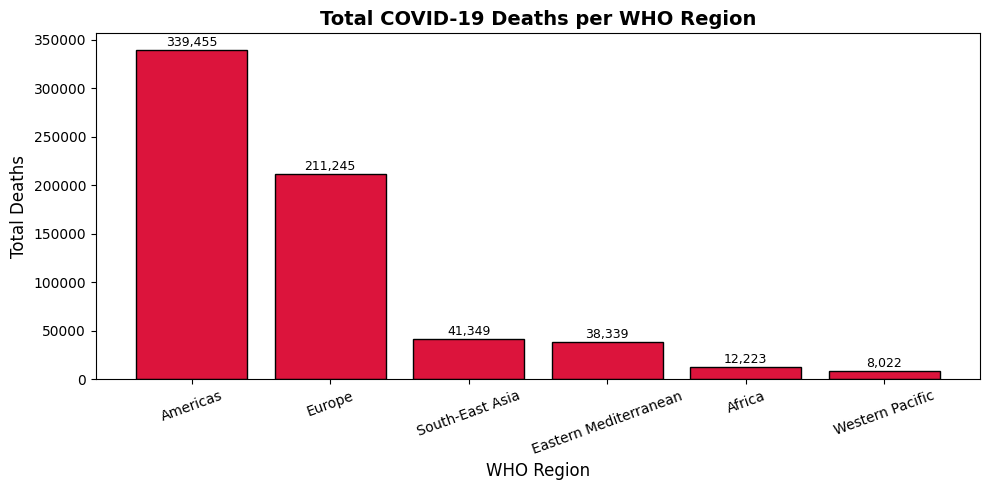

Chart saved as 'deaths_per_region.png'


In [35]:
# Bar chart: Deaths per WHO Region
fig, ax = plt.subplots(figsize=(10, 5))

deaths_sorted = deaths_by_region.sort_values('Total_Deaths', ascending=False)

ax.bar(deaths_sorted['WHO_Region'], deaths_sorted['Total_Deaths'], color='crimson', edgecolor='black')
ax.set_title('Total COVID-19 Deaths per WHO Region', fontsize=14, fontweight='bold')
ax.set_xlabel('WHO Region', fontsize=12)
ax.set_ylabel('Total Deaths', fontsize=12)
ax.tick_params(axis='x', rotation=20)

# Add value labels on bars
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f"{int(bar.get_height()):,}",
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig('deaths_per_region.png', dpi=150)
plt.show()
print("Chart saved as 'deaths_per_region.png'")

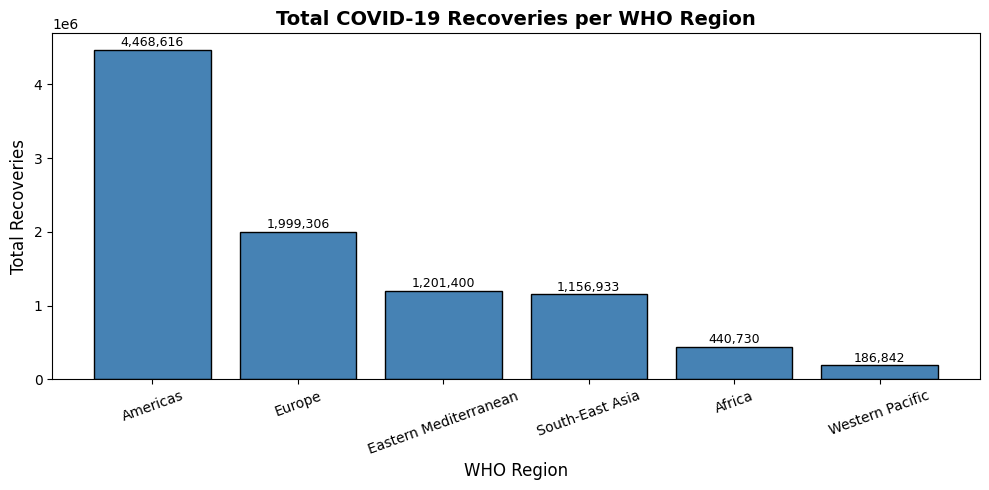

Chart saved as 'recoveries_per_region.png'


In [36]:
# Bar chart: Recoveries per WHO Region
fig, ax = plt.subplots(figsize=(10, 5))

rec_sorted = recoveries_by_region.sort_values('Total_Recovered', ascending=False)

ax.bar(rec_sorted['WHO_Region'], rec_sorted['Total_Recovered'], color='steelblue', edgecolor='black')
ax.set_title('Total COVID-19 Recoveries per WHO Region', fontsize=14, fontweight='bold')
ax.set_xlabel('WHO Region', fontsize=12)
ax.set_ylabel('Total Recoveries', fontsize=12)
ax.tick_params(axis='x', rotation=20)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f"{int(bar.get_height()):,}",
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig('recoveries_per_region.png', dpi=150)
plt.show()
print("Chart saved as 'recoveries_per_region.png'")

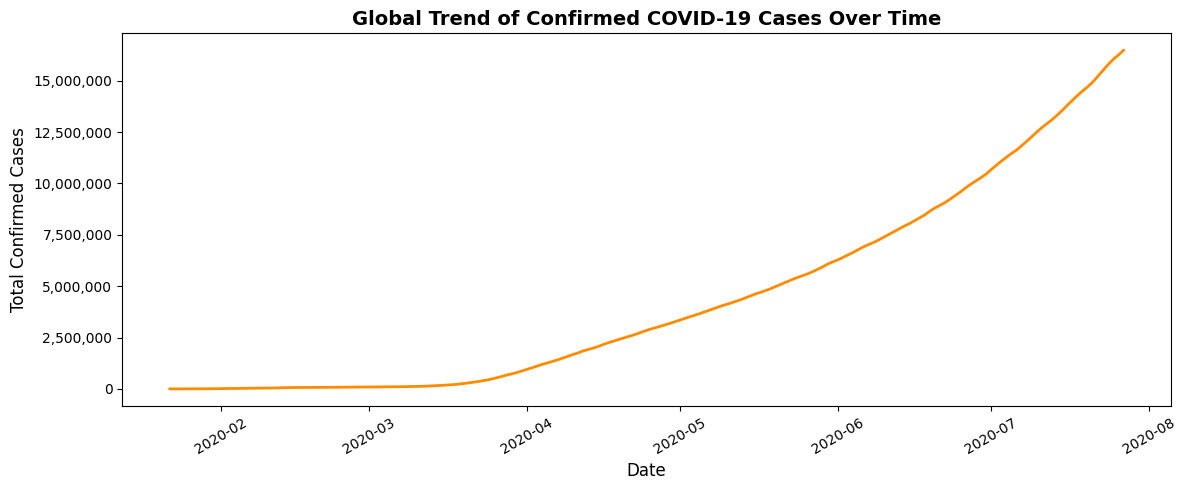

Chart saved as 'confirmed_cases_trend.png'


In [37]:
# Line chart: Trend of confirmed cases over time (global)

# Convert Date to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Aggregate globally per date
global_trend = df_clean.groupby('Date')['Confirmed_Cases'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(global_trend['Date'], global_trend['Confirmed_Cases'],
        color='darkorange', linewidth=2)

ax.set_title('Global Trend of Confirmed COVID-19 Cases Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Confirmed Cases', fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('confirmed_cases_trend.png', dpi=150)
plt.show()
print("Chart saved as 'confirmed_cases_trend.png'")